# **Install and Import Libraries**

In [ ]:
import re
import os
import math
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, recall_score, precision_score

# **Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **1. Enron**

https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset

In [ ]:
enron = pd.read_csv('/content/drive/MyDrive/Dataset/Enron.csv')

In [ ]:
if 'Unnamed: 0' in enron.columns:
    enron.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
enron

,subject,body,label
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0
...,...,...,...
29762,confidence is back,"hello ,\r\nmy boyfriend began having problems ...",1
29763,important information,love - potion for your darling is all you want...,1
29764,vys - make itnger,you have feelings of guilt and embarrassment ...,1
29765,the best thing come in large parcels,spur - m formula\r\nincrease sperm production ...,1


### **Modify Column**

In [ ]:
enron['text'] = enron['subject'].fillna('') + ' ' + enron['body'].fillna('')

In [ ]:
enron.drop(['subject', 'body'], axis=1, inplace = True)

In [ ]:
enron = enron[['text', 'label']]

In [ ]:
enron

,text,label
0,"hpl nom for may 25 , 2001 ( see attached file ...",0
1,re : nom / actual vols for 24 th - - - - - - -...,0
2,"enron actuals for march 30 - april 1 , 201 est...",0
3,"hpl nom for may 30 , 2001 ( see attached file ...",0
4,"hpl nom for june 1 , 2001 ( see attached file ...",0
...,...,...
29762,"confidence is back hello ,\r\nmy boyfriend beg...",1
29763,important information love - potion for your d...,1
29764,vys - make itnger you have feelings of guilt a...,1
29765,the best thing come in large parcels spur - m ...,1


## **2. Ling**

In [ ]:
ling = pd.read_csv('/content/drive/MyDrive/Dataset/Ling.csv')

In [ ]:
if 'Unnamed: 0' in ling.columns:
    ling.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
ling

,subject,body,label
0,job posting - apple-iss research center,content - length : 3386 apple-iss research cen...,0
1,NaN,"lang classification grimes , joseph e . and ba...",0
2,query : letter frequencies for text identifica...,i am posting this inquiry for sergei atamas ( ...,0
3,risk,a colleague and i are researching the differin...,0
4,request book information,earlier this morning i was on the phone with a...,0
...,...,...,...
2854,win $ 300usd and a cruise !,"raquel 's casino , inc . is awarding a cruise ...",1
2855,you have been asked to join kiddin,"the list owner of : "" kiddin "" has invited you...",1
2856,anglicization of composers ' names,"judging from the return post , i must have sou...",0
2857,"re : 6 . 797 , comparative method : n - ary co...",gotcha ! there are two separate fallacies in t...,0


### **Modify Column**

In [ ]:
ling['text'] = ling['subject'].fillna('') + ' ' + ling['body'].fillna('')

In [ ]:
ling.drop(['subject', 'body'], axis=1, inplace = True)

In [ ]:
ling = ling[['text', 'label']]

In [ ]:
ling

,text,label
0,job posting - apple-iss research center conten...,0
1,"lang classification grimes , joseph e . and b...",0
2,query : letter frequencies for text identifica...,0
3,risk a colleague and i are researching the dif...,0
4,request book information earlier this morning ...,0
...,...,...
2854,"win $ 300usd and a cruise ! raquel 's casino ,...",1
2855,you have been asked to join kiddin the list ow...,1
2856,anglicization of composers ' names judging fro...,0
2857,"re : 6 . 797 , comparative method : n - ary co...",0


## **3. CEAS_08**

In [ ]:
CEAS = pd.read_csv('/content/drive/MyDrive/Dataset/CEAS_08.csv')

In [ ]:
if 'Unnamed: 0' in CEAS.columns:
    CEAS.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
CEAS

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1
...,...,...,...,...,...,...,...
39149,CNN Alerts <charlene-detecton@btcmarketing.com>,email1007@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:34:50 -0400",CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0
39150,CNN Alerts <idgetily1971@careplusnj.org>,email104@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:35:11 -0400",CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0
39151,Abhijit Vyas <xpojhbz@gmail.com>,fxgmqwjn@triptracker.net,"Fri, 08 Aug 2008 22:00:43 +0800",Slideshow viewer,Hello there ! \nGreat work on the slide show v...,0,0
39152,Joseph Brennan <vupzesm@columbia.edu>,zqoqi@spamassassin.apache.org,"Fri, 08 Aug 2008 09:00:46 -0500",Note on 2-digit years,"\nMail from sender , coming from intuit.com\ns...",0,0


### **Modify Column**

In [ ]:
CEAS.drop(['sender', 'receiver', 'date', 'urls'], axis=1, inplace = True)

In [ ]:
CEAS['text'] = CEAS['subject'].fillna('') + ' ' + CEAS['body'].fillna('')

In [ ]:
CEAS.drop(['subject', 'body'], axis=1, inplace = True)

In [ ]:
CEAS = CEAS[['text', 'label']]

In [ ]:
CEAS

,text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1
...,...,...
39149,CNN Alerts: My Custom Alert \n\nCNN Alerts: My...,1
39150,CNN Alerts: My Custom Alert \n\nCNN Alerts: My...,1
39151,Slideshow viewer Hello there ! \nGreat work on...,0
39152,"Note on 2-digit years \nMail from sender , com...",0


## **4. Nazario**

In [ ]:
nazario = pd.read_csv('/content/drive/MyDrive/Dataset/Nazario.csv')

In [ ]:
if 'Unnamed: 0' in nazario.columns:
    nazario.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
nazario

,sender,receiver,date,subject,body,urls,label
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1
3,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>","Fri, 30 Oct 2015 14:54:33 +0000",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0,1
4,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,"Fri, 30 Oct 2015 14:02:33 -0500",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1,1
...,...,...,...,...,...,...,...
1560,info advantageapartments.com <info@advantageap...,"""jose@monkey.org"" <jose@monkey.org>","Sun, 11 Dec 2022 12:04:50 +0000",Receipt for Your Payment to FTX.,PayPal You sent a payment of $699.99 USD to FT...,0,1
1561,monkey.org <HELPDESK@monkey.org>,jose@monkey.org,15 Dec 2022 18:33:00 -0500,Rectify Your Password With monkey.org,"monkey.org Hi jose,Pa⁠s⁠sword for⁠ jose@monke...",1,1
1562,Help Center\n\t<info.help-center.co.za_info.he...,jose@monkey.org,"Tue, 20 Dec 2022 23:00:27 +0000 (UTC)",Netflix : We're having some trouble with your ...,"HELLO, Please note that, your monthly paymen...",1,1
1563,MetaMask <info@sofamekar.com>,jose@monkey.org,27 Dec 2022 10:56:49 +0800,Your MetaMask wallet will be suspended,Verify your MetaMask Wallet Our system has sho...,1,1


### **Modify Column**

In [ ]:
nazario.drop(['sender', 'receiver', 'date', 'urls'], axis=1, inplace = True)

In [ ]:
nazario['text'] = nazario['subject'].fillna('') + ' ' + nazario['body'].fillna('')

In [ ]:
nazario.drop(['subject', 'body'], axis=1, inplace = True)

In [ ]:
nazario = nazario[['text', 'label']]

In [ ]:
nazario

,text,label
0,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL D...,1
1,Verify Your Account Business with \t\t\t\t\t\...,1
2,Helpdesk Mailbox Alert!!! Your two incoming ma...,1
3,IT-Service Help Desk Password will expire in 3...,1
4,Final USAA Reminder - Update Your Account Now ...,1
...,...,...
1560,Receipt for Your Payment to FTX. PayPal You se...,1
1561,Rectify Your Password With monkey.org monkey.o...,1
1562,Netflix : We're having some trouble with your ...,1
1563,Your MetaMask wallet will be suspended Verify ...,1


## **5. Nigerian_Fraud**

In [ ]:
nigerian = pd.read_csv('/content/drive/MyDrive/Dataset/Nigerian_Fraud.csv')

In [ ]:
if 'Unnamed: 0' in nigerian.columns:
    nigerian.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
nigerian

,sender,receiver,date,subject,body,urls,label
0,MR. JAMES NGOLA. <james_ngola2002@maktoob.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 02:38:20 +0000",URGENT BUSINESS ASSISTANCE AND PARTNERSHIP,FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-2...,0,1
1,Mr. Ben Suleman <bensul2004nng@spinfinder.com>,R@M,"Thu, 31 Oct 2002 05:10:00 -0000",URGENT ASSISTANCE /RELATIONSHIP (P),"Dear Friend,\n\nI am Mr. Ben Suleman a custom ...",0,1
2,PRINCE OBONG ELEME <obong_715@epatra.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 22:17:55 +0100",GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,0,1
3,PRINCE OBONG ELEME <obong_715@epatra.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 22:44:20 -0000",GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,0,1
4,Maryam Abacha <m_abacha03@www.com>,R@M,"Fri, 01 Nov 2002 01:45:04 +0100",I Need Your Assistance.,"Dear sir, \n \nIt is with a heart full of hope...",0,1
...,...,...,...,...,...,...,...
3327,michealagu0255@zipmail.com.br,NaN,NaN,CONTACT GLOBAL MAX SHIPING COMPANY,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1
3328,ali sherif <ali_sherif252@hotmail.fr>,NaN,"Mon, 17 Sep 2007 22:28:11 +0000",TREAT AS URGENT.,\nFrom: Mr Ali Sherif. African Development Ban...,1,1
3329,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,NaN,"Tue, 18 Sep 2007 10:54:53 +0000",From Dr Usman Ibrahim / Mr Wahid Yoffe property.,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,1
3330,Mother Doris Killam <motherdorisk61@hotmail.com>,NaN,"Wed, 19 Sep 2007 00:52:16 +0100",My Beloved In Christ.,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,1


### **Modify Column**

In [ ]:
nigerian.drop(['sender', 'receiver', 'date', 'urls'], axis=1, inplace = True)

In [ ]:
nigerian['text'] = nigerian['subject'].fillna('') + ' ' + nigerian['body'].fillna('')

In [ ]:
nigerian.drop(['subject', 'body'], axis=1, inplace = True)

In [ ]:
nigerian = nigerian[['text', 'label']]

In [ ]:
nigerian

,text,label
0,URGENT BUSINESS ASSISTANCE AND PARTNERSHIP FRO...,1
1,URGENT ASSISTANCE /RELATIONSHIP (P) Dear Frien...,1
2,GOOD DAY TO YOU FROM HIS ROYAL MAJESTY (HRM) C...,1
3,GOOD DAY TO YOU FROM HIS ROYAL MAJESTY (HRM) C...,1
4,"I Need Your Assistance. Dear sir, \n \nIt is w...",1
...,...,...
3327,CONTACT GLOBAL MAX SHIPING COMPANY Atten: My D...,1
3328,TREAT AS URGENT. \nFrom: Mr Ali Sherif. Africa...,1
3329,From Dr Usman Ibrahim / Mr Wahid Yoffe propert...,1
3330,My Beloved In Christ. \nBeloved in the Lord ...,1


## **6. SpamAssasin**

In [ ]:
assasin = pd.read_csv('/content/drive/MyDrive/Dataset/SpamAssasin.csv')

In [ ]:
if 'Unnamed: 0' in assasin.columns:
    assasin.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
assasin

,sender,receiver,date,subject,body,label,urls
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,1
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,1
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,1
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient: ;,"Thu, 22 Aug 2002 09:15:25 -0400",[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0,1
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100",Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0,1
...,...,...,...,...,...,...,...
5804,Professional_Career_Development_Institute@Frug...,yyyy@netnoteinc.com,"Tue, 3 Dec 2002 13:19:58 -0800",Busy? Home Study Makes Sense!,\n\n \n--- \n![](http://images.pcdi-homestud...,1,1
5805,"""IQ - TBA"" <tba@insiq.us>",<yyyy@spamassassin.taint.org>,"Tue, 3 Dec 2002 18:52:29 -0500",Preferred Non-Smoker Rates for Smokers,This is a multi-part message in MIME format. -...,1,1
5806,Mike <raye@yahoo.lv>,Mailing.List@user2.pro-ns.net,"Sun, 20 Jul 2003 16:19:44 +0800","How to get 10,000 FREE hits per day to any web...","Dear Subscriber,\n\nIf I could show you a way ...",1,1
5807,"""Mr. Clean"" <cweqx@dialix.oz.au>",<Undisclosed.Recipients@webnote.net>,"Wed, 05 Aug 2020 04:01:50 -1900",Cannabis Difference,****Mid-Summer Customer Appreciation SALE!****...,1,0


### **Modify Column**

In [ ]:
assasin.drop(['sender', 'receiver', 'date', 'urls'], axis=1, inplace = True)

In [ ]:
assasin['text'] = assasin['subject'].fillna('') + ' ' + assasin['body'].fillna('')

In [ ]:
assasin.drop(['subject', 'body'], axis=1, inplace = True)

In [ ]:
assasin = assasin[['text', 'label']]

In [ ]:
assasin

,text,label
0,"Re: New Sequences Window Date: Wed, 21 ...",0
1,[zzzzteana] RE: Alexander Martin A posted:\nTa...,0
2,[zzzzteana] Moscow bomber Man Threatens Explos...,0
3,[IRR] Klez: The Virus That Won't Die Klez: Th...,0
4,Re: [zzzzteana] Nothing like mama used to make...,0
...,...,...
5804,Busy? Home Study Makes Sense! \n\n \n--- \n!...,1
5805,Preferred Non-Smoker Rates for Smokers This is...,1
5806,"How to get 10,000 FREE hits per day to any web...",1
5807,Cannabis Difference ****Mid-Summer Customer Ap...,1


## **7. Email**

https://www.kaggle.com/datasets/ashfakyeafi/spam-email-classification

In [ ]:
email = pd.read_csv('/content/drive/MyDrive/Dataset/email.csv')

In [ ]:
if 'Unnamed: 0' in email.columns:
    email.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
email

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


### **Modify Column**

In [ ]:
email.rename(columns={'Category':'label', 'Message':'text'}, inplace=True)

In [ ]:
email = email[:-1]

In [ ]:
email['label'] = email['label'].map({'ham': 0, 'spam': 1})

/tmp/ipython-input-54-1321777491.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  email['label'] = email['label'].map({'ham': 0, 'spam': 1})


In [ ]:
email = email[['text', 'label']]

In [ ]:
email

,text,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1
5568,Will ü b going to esplanade fr home?,0
5569,"Pity, * was in mood for that. So...any other s...",0
5570,The guy did some bitching but I acted like i'd...,0


## **8. Phishing_Email**

https://www.kaggle.com/datasets/subhajournal/phishingemails

In [ ]:
phish_email = pd.read_csv('/content/drive/MyDrive/Dataset/Phishing_Email.csv')

/tmp/ipython-input-57-2457763353.py:1: DtypeWarning: Columns (0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185) have mixed types. Specify dtype option on import or set low_memory=False.
  phish_email = pd.read_csv('/content/drive/MyDrive/Dataset/Phishing_Email.csv')


In [ ]:
phish_email = phish_email[['Email Text', 'Email Type']]
phish_email

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email
...,...,...
3786,"URL: http://www.newsisfree.com/click/-5,855354...",Safe Email
3787,bounce skel @ iit . demokritos . gr : non - me...,Phishing Email
3788,"h e l l od e a rh o m eo w n e r , w eh a v eb...",Phishing Email
3789,california capacity report for week of 01 / 14...,Safe Email


### **Modify Column**

In [ ]:
phish_email.rename(columns={'Email Text':'text', 'Email Type':'label'}, inplace=True)

In [ ]:
# Map the labels, which might result in NaN for unmapped values
phish_email['label'] = phish_email['label'].map({'Safe Email': 0, 'Phishing Email': 1})

# Fill any NaN values in the 'label' column with 0 before converting to int
phish_email['label'] = phish_email['label'].fillna(0).astype(int)

In [ ]:
phish_email = phish_email[['text', 'label']]

In [ ]:
phish_email

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1
...,...,...
3786,"URL: http://www.newsisfree.com/click/-5,855354...",0
3787,bounce skel @ iit . demokritos . gr : non - me...,1
3788,"h e l l od e a rh o m eo w n e r , w eh a v eb...",1
3789,california capacity report for week of 01 / 14...,0


## **9. spam_Emails_data**

https://www.kaggle.com/datasets/meruvulikith/190k-spam-ham-email-dataset-for-classification

In [ ]:
spam_email = pd.read_csv('/content/drive/MyDrive/Dataset/spam_Emails_data.csv')

In [ ]:
if 'Unnamed: 0' in spam_email.columns:
    spam_email.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
spam_email

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...
...,...,...
193847,Ham,on escapenumber escapenumber escapenumber rob ...
193848,Spam,we have everything you need escapelong cialesc...
193849,Ham,hi quick question say i have a date variable i...
193850,Spam,thank you for your loan request which we recie...


### **Modify Column**

In [ ]:
spam_email['label'] = spam_email['label'].map({'Ham': 0, 'Spam': 1})

In [ ]:
spam_email = spam_email[['text', 'label']]

In [ ]:
spam_email

,text,label
0,viiiiiiagraaaa\nonly for the ones that want to...,1
1,got ice thought look az original message ice o...,0
2,yo ur wom an ne eds an escapenumber in ch ma n...,1
3,start increasing your odds of success & live s...,1
4,author jra date escapenumber escapenumber esca...,0
...,...,...
193847,on escapenumber escapenumber escapenumber rob ...,0
193848,we have everything you need escapelong cialesc...,1
193849,hi quick question say i have a date variable i...,0
193850,thank you for your loan request which we recie...,1


## **10. combined_data**

https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset

In [ ]:
combined_data = pd.read_csv('/content/drive/MyDrive/Dataset/combined_data.csv')

In [ ]:
if 'Unnamed: 0' in combined_data.columns:
    combined_data.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
combined_data

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
...,...,...
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...


### **Modify Column**

In [ ]:
combined_data = combined_data[['text', 'label']]

In [ ]:
combined_data

,text,label
0,ounce feather bowl hummingbird opec moment ala...,1
1,wulvob get your medircations online qnb ikud v...,1
2,computer connection from cnn com wednesday es...,0
3,university degree obtain a prosperous future m...,1
4,thanks for all your answers guys i know i shou...,0
...,...,...
83443,hi given a date how do i get the last date of ...,0
83444,now you can order software on cd or download i...,1
83445,dear valued member canadianpharmacy provides a...,1
83446,subscribe change profile contact us long term ...,0


## **11. combined_enron**

https://www.kaggle.com/datasets/haldonmez/spam-or-ham-a-dataset-for-email-classification

In [ ]:
combined_enron = pd.read_csv('/content/drive/MyDrive/Dataset/combined_enron.csv')

In [ ]:
if 'Unnamed: 0' in combined_enron.columns:
    combined_enron.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
combined_enron

,label,label_num,text
0,ham,0,subject fw weather sites this is the list of w...
1,spam,1,subject i cant believe the changma wow wow wow...
2,spam,1,subject 4 color printing special request addit...
3,spam,1,subject nobody can beat us poloponybreakaway i...
4,ham,0,subject energy extravaganza 2 weeks away energ...
...,...,...,...
33697,ham,0,subject enron mentions enron jolt investments ...
33698,ham,0,subject hpl meter 981295 hungerford grain comp...
33699,ham,0,subject re expenses tammie has the receipts fr...
33700,spam,1,subject comparison report ciearance bundle 1 w...


### **Modify Column**

In [ ]:
combined_enron.drop(['label'], axis=1, inplace = True)

In [ ]:
combined_enron.rename(columns={'label_num':'label'}, inplace=True)

In [ ]:
combined_enron = combined_enron[['text', 'label']]

In [ ]:
combined_enron

,text,label
0,subject fw weather sites this is the list of w...,0
1,subject i cant believe the changma wow wow wow...,1
2,subject 4 color printing special request addit...,1
3,subject nobody can beat us poloponybreakaway i...,1
4,subject energy extravaganza 2 weeks away energ...,0
...,...,...
33697,subject enron mentions enron jolt investments ...,0
33698,subject hpl meter 981295 hungerford grain comp...,0
33699,subject re expenses tammie has the receipts fr...,0
33700,subject comparison report ciearance bundle 1 w...,1


## **12. email_text**

https://www.kaggle.com/datasets/bayes2003/emails-for-spam-or-ham-classification-spamassassin?select=email_text.csv

In [ ]:
email_text = pd.read_csv('/content/drive/MyDrive/Dataset/email_text.csv')

In [ ]:
if 'Unnamed: 0' in email_text.columns:
    email_text.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
email_text

,label,text
0,0,me spam is the tool for dissident news since t...
1,0,escapenumber escapenumber escapenumber penguin...
2,0,on wednesday escapenumber july escapenumber es...
3,0,can't think of how i'd be running afoul of th...
4,0,forwarded by william knowles http www thesun c...
...,...,...
5635,1,you are receiving this email because you have ...
5636,1,royal meds com your online pharmacy · www roya...
5637,1,your attention please please reply only to esc...
5638,1,tremendous savings on toners inkjets fax and t...


### **Modify Column**

In [ ]:
email_text = email_text[['text', 'label']]

In [ ]:
email_text

,text,label
0,me spam is the tool for dissident news since t...,0
1,escapenumber escapenumber escapenumber penguin...,0
2,on wednesday escapenumber july escapenumber es...,0
3,can't think of how i'd be running afoul of th...,0
4,forwarded by william knowles http www thesun c...,0
...,...,...
5635,you are receiving this email because you have ...,1
5636,royal meds com your online pharmacy · www roya...,1
5637,your attention please please reply only to esc...,1
5638,tremendous savings on toners inkjets fax and t...,1


## **13. spam_or_not_spam**

https://www.kaggle.com/datasets/ozlerhakan/spam-or-not-spam-dataset

In [ ]:
spam_or_not_spam = pd.read_csv('/content/drive/MyDrive/Dataset/spam_or_not_spam.csv')

In [ ]:
if 'Unnamed: 0' in spam_or_not_spam.columns:
    spam_or_not_spam.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
spam_or_not_spam

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0
...,...,...
2995,abc s good morning america ranks it the NUMBE...,1
2996,hyperlink hyperlink hyperlink let mortgage le...,1
2997,thank you for shopping with us gifts for all ...,1
2998,the famous ebay marketing e course learn to s...,1


### **Modify Column**

In [ ]:
spam_or_not_spam.rename(columns={'email':'text'}, inplace=True)

In [ ]:
spam_or_not_spam

,text,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0
...,...,...
2995,abc s good morning america ranks it the NUMBE...,1
2996,hyperlink hyperlink hyperlink let mortgage le...,1
2997,thank you for shopping with us gifts for all ...,1
2998,the famous ebay marketing e course learn to s...,1


## **14. spam_email_dataset**

https://www.kaggle.com/datasets/zeeshier/spam-email-dataset

In [ ]:
spam_email_dataset = pd.read_csv('/content/drive/MyDrive/Dataset/spam_email_dataset.csv', encoding='latin-1')

In [ ]:
if 'Unnamed: 0' in spam_email_dataset.columns:
    spam_email_dataset.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
spam_email_dataset

,Subject,Body,Spam Label
0,Exclusive Loan Offer  Get Instant Approval,Alert!\n\nYour computer has been infected with...,1
1,Meeting Agenda for Tomorrow,"Dear Student,\n\nThis is a reminder about your...",0
2,Quarterly Sales Report Attached,"Hey,\n\nIm sharing the travel itinerary for o...",0
3,Exclusive Loan Offer  Get Instant Approval,"Dear Investor,\n\nDon't miss this incredible i...",1
4,"Win $1,000,000 Now  Limited Time Offer!","Dear Customer,\n\nWe are giving away free holi...",1
...,...,...,...
1495,"Work From Home & Earn $10,000/Week!",Alert!\n\nYour computer has been infected with...,1
1496,Order Confirmation  Thank You!,"Dear Alice,\n\nYour subscription has been succ...",0
1497,"Win $1,000,000 Now  Limited Time Offer!","Dear Valued Customer,\n\nYou have won a grand ...",1
1498,Act Fast! Your Netflix Subscription Is Expiring,"Hi,\n\nYour Amazon account has been locked due...",1


### **Modify Column**

In [ ]:
spam_email_dataset.rename(columns={'Spam Label':'label'}, inplace=True)

In [ ]:
spam_email_dataset['text'] = spam_email_dataset['Subject'].fillna('') + ' ' + spam_email_dataset['Body'].fillna('')

In [ ]:
spam_email_dataset.drop(['Subject', 'Body'], axis=1, inplace = True)

In [ ]:
spam_email_dataset = spam_email_dataset[['text', 'label']]

In [ ]:
spam_email_dataset

,text,label
0,Exclusive Loan Offer  Get Instant Approval Al...,1
1,"Meeting Agenda for Tomorrow Dear Student,\n\nT...",0
2,"Quarterly Sales Report Attached Hey,\n\nIm sh...",0
3,Exclusive Loan Offer  Get Instant Approval De...,1
4,"Win $1,000,000 Now  Limited Time Offer! Dear ...",1
...,...,...
1495,"Work From Home & Earn $10,000/Week! Alert!\n\n...",1
1496,"Order Confirmation  Thank You! Dear Alice,\n\...",0
1497,"Win $1,000,000 Now  Limited Time Offer! Dear ...",1
1498,Act Fast! Your Netflix Subscription Is Expirin...,1


## **15. phishing_Full_dataset**

https://www.kaggle.com/datasets/sandeepamunasingha/phishing-email-detection

In [ ]:
phishing_Full_dataset = pd.read_csv('/content/drive/MyDrive/Dataset/phishing_Full_dataset.csv', encoding='latin-1')

In [ ]:
if 'Unnamed: 0' in phishing_Full_dataset.columns:
    phishing_Full_dataset.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
phishing_Full_dataset

,Text,label
0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,0
1,What's up? Do you want me to come online? If y...,0
2,So u workin overtime nigpun?,0
3,"Also sir, i sent you an email about how to log...",0
4,Please Stay At Home. To encourage the notion o...,1
...,...,...
157089,Busy? Home Study Makes Sense! \n\n \n--- \n!...,1
157090,Preferred Non-Smoker Rates for Smokers This is...,1
157091,"How to get 10,000 FREE hits per day to any web...",1
157092,Cannabis Difference ****Mid-Summer Customer Ap...,1


### **Modify Column**

In [ ]:
phishing_Full_dataset.rename(columns={'Text':'text'}, inplace=True)

In [ ]:
phishing_Full_dataset

,text,label
0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,0
1,What's up? Do you want me to come online? If y...,0
2,So u workin overtime nigpun?,0
3,"Also sir, i sent you an email about how to log...",0
4,Please Stay At Home. To encourage the notion o...,1
...,...,...
157089,Busy? Home Study Makes Sense! \n\n \n--- \n!...,1
157090,Preferred Non-Smoker Rates for Smokers This is...,1
157091,"How to get 10,000 FREE hits per day to any web...",1
157092,Cannabis Difference ****Mid-Summer Customer Ap...,1


## **16. TREC07**

https://www.kaggle.com/datasets/rohansood98/phishing-email-dataset-nazario-5-and-trec07?select=email_text.csv

In [ ]:
TREC07 = pd.read_csv('/content/drive/MyDrive/Dataset/TREC07.csv', encoding='latin-1')

In [ ]:
if 'Unnamed: 0' in TREC07.columns:
    TREC07.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
TREC07

,label,text
0,1,do you feel the pressure to perform and not ri...
1,0,hi i've just updated from the gulus and i chec...
2,1,mega authenticv i a g r a discount pricec i a ...
3,1,hey billy it was really fun going out the othe...
4,1,system of the home it will have the capabiliti...
...,...,...
53663,1,versuchen sie unser produkt und sie werden fuh...
53664,1,while we may have high expectations of our ass...
53665,0,for those who are interested i just cook a lit...
53666,0,hello as i wrote i call sqlfetch channel t stu...


### **Modify Column**

In [ ]:
TREC07 = spam_email_dataset[['text', 'label']]

In [ ]:
TREC07

,text,label
0,Exclusive Loan Offer  Get Instant Approval Al...,1
1,"Meeting Agenda for Tomorrow Dear Student,\n\nT...",0
2,"Quarterly Sales Report Attached Hey,\n\nIm sh...",0
3,Exclusive Loan Offer  Get Instant Approval De...,1
4,"Win $1,000,000 Now  Limited Time Offer! Dear ...",1
...,...,...
1495,"Work From Home & Earn $10,000/Week! Alert!\n\n...",1
1496,"Order Confirmation  Thank You! Dear Alice,\n\...",0
1497,"Win $1,000,000 Now  Limited Time Offer! Dear ...",1
1498,Act Fast! Your Netflix Subscription Is Expirin...,1


## **17. labeled_emails**

https://www.kaggle.com/datasets/juanagsolano/spam-email-from-enron-dataset

In [ ]:
labeled_emails = pd.read_csv('/content/drive/MyDrive/Dataset/labeled_emails.csv', encoding='latin-1')

In [ ]:
if 'Unnamed: 0' in labeled_emails.columns:
    labeled_emails.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
labeled_emails

,email,label
0,Subject: re : rankings\nthank you .,ham
1,"Subject: re : visit to enron\nvince ,\ndec . 2...",ham
2,Subject: research group move to the 19 th floo...,ham
3,Subject: christmas baskets\nthe christmas bask...,ham
4,"Subject: japan candidate\nvince ,\ni spoke wit...",ham
...,...,...
5849,"Subject: tetm : 22 , interest : 3 . 55 %\nha h...",spam
5850,"Subject: localized software , all languages av...",spam
5851,Subject: instant branded software download\nso...,spam
5852,"Subject: localized software , all languages av...",spam


### **Modify Column**

In [ ]:
labeled_emails.rename(columns={'email':'text'}, inplace=True)

In [ ]:
labeled_emails['label'] = labeled_emails['label'].map({'ham': 0, 'spam': 1})

In [ ]:
labeled_emails

,text,label
0,Subject: re : rankings\nthank you .,0
1,"Subject: re : visit to enron\nvince ,\ndec . 2...",0
2,Subject: research group move to the 19 th floo...,0
3,Subject: christmas baskets\nthe christmas bask...,0
4,"Subject: japan candidate\nvince ,\ni spoke wit...",0
...,...,...
5849,"Subject: tetm : 22 , interest : 3 . 55 %\nha h...",1
5850,"Subject: localized software , all languages av...",1
5851,Subject: instant branded software download\nso...,1
5852,"Subject: localized software , all languages av...",1


## **18. Email Spam**

https://www.kaggle.com/datasets/khashayarahmadi/email-spam

In [ ]:
emailSpam = pd.read_csv('/content/drive/MyDrive/Dataset/emailSpam.csv', encoding='latin-1')

In [ ]:
if 'Unnamed: 0' in emailSpam.columns:
    emailSpam.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
emailSpam

,email,category
0,"URL: http://www.newsisfree.com/click/-1,817167...",not-spam
1,"On Thu, 19 Sep 2002, Bill Stoddard wrote:\n\n-...",not-spam
2,Dan Kohn <dan@dankohn.com> writes:\n\n\n\n> Gu...,not-spam
3,wintermute wrote:\n\n>>Anyone know where in Ir...,not-spam
4,"I attended the same conference, and was impres...",not-spam
...,...,...
3791,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",spam
3792,<html>\n\n<HEAD> \n\n<TITLE>creditfix</TITLE> ...,spam
3793,Hello:\n\n\n\nAre you satisfied with your ISP?...,spam
3794,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,spam


### **Modify Column**

In [ ]:
emailSpam.rename(columns={'email':'text', 'category':'label'}, inplace=True)

In [ ]:
emailSpam['label'] = emailSpam['label'].map({'not-spam': 0, 'spam': 1})

In [ ]:
emailSpam

,text,label
0,"URL: http://www.newsisfree.com/click/-1,817167...",0
1,"On Thu, 19 Sep 2002, Bill Stoddard wrote:\n\n-...",0
2,Dan Kohn <dan@dankohn.com> writes:\n\n\n\n> Gu...,0
3,wintermute wrote:\n\n>>Anyone know where in Ir...,0
4,"I attended the same conference, and was impres...",0
...,...,...
3791,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",1
3792,<html>\n\n<HEAD> \n\n<TITLE>creditfix</TITLE> ...,1
3793,Hello:\n\n\n\nAre you satisfied with your ISP?...,1
3794,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,1


# **Combine Datasets**

In [ ]:
combined_final = pd.concat([enron, ling, CEAS, nazario, nigerian, assasin, email, phish_email,
                            spam_email, combined_data, combined_enron, email_text, spam_or_not_spam,
                            spam_email_dataset, phishing_Full_dataset, TREC07, labeled_emails, emailSpam], ignore_index=True)

In [ ]:
combined_final

,text,label
0,"hpl nom for may 25 , 2001 ( see attached file ...",0
1,re : nom / actual vols for 24 th - - - - - - -...,0
2,"enron actuals for march 30 - april 1 , 201 est...",0
3,"hpl nom for may 30 , 2001 ( see attached file ...",0
4,"hpl nom for june 1 , 2001 ( see attached file ...",0
...,...,...
581230,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",1
581231,<html>\n\n<HEAD> \n\n<TITLE>creditfix</TITLE> ...,1
581232,Hello:\n\n\n\nAre you satisfied with your ISP?...,1
581233,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,1


label
0    299886
1    281349
Name: count, dtype: int64


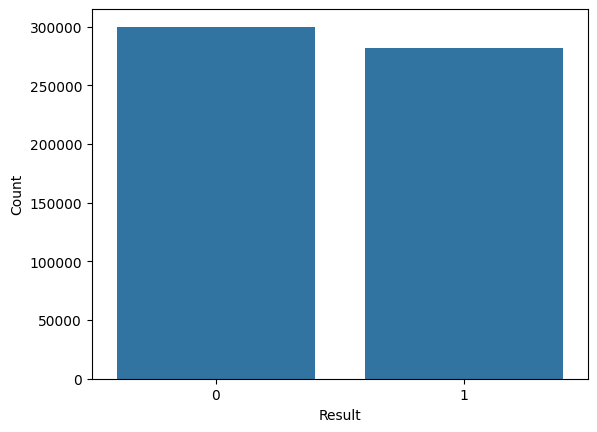

In [ ]:
print(combined_final['label'].value_counts())
sns.countplot(x='label', data=combined_final)
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

## **Clean Combined Dataset**

In [ ]:
combined_final.duplicated().sum()

np.int64(142840)

In [ ]:
last_df = combined_final.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)

In [ ]:
last_df.duplicated().sum()

np.int64(0)

In [ ]:
last_df.to_csv('phishEmail.csv')

label
0    229190
1    209199
Name: count, dtype: int64


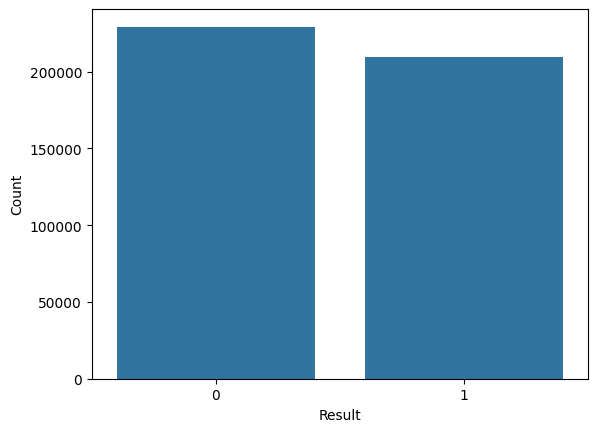

In [ ]:
print(last_df['label'].value_counts())
sns.countplot(x='label', data=last_df)
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

In [ ]:
last_df

,text,label
0,"hpl nom for may 25 , 2001 ( see attached file ...",0
1,re : nom / actual vols for 24 th - - - - - - -...,0
2,"enron actuals for march 30 - april 1 , 201 est...",0
3,"hpl nom for may 30 , 2001 ( see attached file ...",0
4,"hpl nom for june 1 , 2001 ( see attached file ...",0
...,...,...
438384,"Attention Homeowners, \n\n\n\n""Now is the time...",1
438385,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",1
438386,Hello:\n\n\n\nAre you satisfied with your ISP?...,1
438387,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,1


In [ ]:
a = pd.read_csv('/content/drive/MyDrive/Dataset/phishEmail.csv')

In [ ]:
a

,Unnamed: 0,text,label
0,0,"hpl nom for may 25 , 2001 ( see attached file ...",0
1,1,re : nom / actual vols for 24 th - - - - - - -...,0
2,2,"enron actuals for march 30 - april 1 , 201 est...",0
3,3,"hpl nom for may 30 , 2001 ( see attached file ...",0
4,4,"hpl nom for june 1 , 2001 ( see attached file ...",0
...,...,...,...
438384,438384,"Attention Homeowners, \n\n\n\n""Now is the time...",1
438385,438385,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",1
438386,438386,Hello:\n\n\n\nAre you satisfied with your ISP?...,1
438387,438387,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,1
